# 数据读取 （data from Unit03_1_5_select.mat）

## 原始数据的读取

In [1]:
import scipy.io
import numpy as np

# ==================== 1️⃣ 读取 .mat 文件 ====================
mat_data = scipy.io.loadmat(
    '/home/charles/HZU/Data_processed/multi-condition-transfer-learning/Unit03_1_5_select_4.mat'
)

data = mat_data['Unit03_1_5_select_4']

print("Original data shape:", data.shape)  # (N, 14)

# ==================== 2️⃣ 设置抽样参数 ====================
n = 5000        # ⭐你只需要改这里
seed = 42      # 可选：保证可复现

np.random.seed(seed)

num_samples = data.shape[0]
assert n <= num_samples, "n cannot be larger than total samples!"

# ==================== 3️⃣ 随机抽取 n 个样本（行） ====================
indices = np.random.choice(num_samples, size=n, replace=False)
data = data[indices, :]

print("Sampled data shape:", data.shape)

# ==================== 4️⃣ 查看抽样结果 ====================
print(data[:5])   # 前 5 行看看


Original data shape: (120000, 14)
Sampled data shape: (5000, 14)
[[ 6.44879007e+00  9.89900780e+00  1.90707862e-01 -1.08997412e+01
   2.62183411e+02  3.11502747e+02  5.61110718e+02  8.06992188e+02
   7.92810608e+02  8.95006958e+02  7.50036987e+02  7.48097046e+02
   7.48671387e+02  2.98820686e+00]
 [ 6.53146410e+00  9.83751106e+00  1.89284369e-01 -1.14709768e+01
   2.62158813e+02  3.12536133e+02  5.60454041e+02  8.14469238e+02
   8.00921570e+02  8.94770813e+02  7.51456848e+02  7.48712585e+02
   7.49641296e+02  4.64089346e+00]
 [ 6.56376362e+00  9.10135174e+00  1.71239838e-01 -1.40106335e+01
   2.62777527e+02  3.08556671e+02  5.62043396e+02  8.09128113e+02
   7.98723511e+02  8.97193604e+02  7.49260986e+02  7.47456848e+02
   7.48115967e+02  2.35006785e+00]
 [ 6.33066225e+00  9.98306084e+00  1.95128351e-01 -1.39515629e+01
   2.63632294e+02  3.07687988e+02  5.75290466e+02  8.21349548e+02
   8.02239624e+02  9.05823181e+02  7.48023193e+02  7.48449585e+02
   7.47242065e+02  8.73057747e+00]
 [ 

## 特征和标签的分离

In [2]:
import numpy as np

# 假设 'data' 是一个二维数组或矩阵
# 分离特征和标签

# 特征是除了最后一列的数据
X = data[:, :-1]  # 所有行，去除最后一列

# 标签是最后一列的数据
y = data[:, -1]  # 所有行，只取最后一列
y = y.reshape(-1, 1)

# # 查看特征和标签
# print("Features (X):")
# print(X[:5])  # 查看前5个特征样本
# print("Labels (y):")
# print(y[:5])  # 查看前5个标签

# 查看特征和标签的形状
print("Shape of Features (X):", X.shape)
print("Shape of Labels (y):", y.shape)

Shape of Features (X): (5000, 13)
Shape of Labels (y): (5000, 1)


## 三集划分

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

# 假设 X 和 y 是已经分离好的特征和标签
# X: 特征数据，y: 标签数据

# 设置随机种子，确保结果可复现
random_seed = 42

# 控制三集的划分比例：例如 70% 训练集，15% 验证集，15% 测试集
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# 确保划分比例之和为1
assert train_ratio + val_ratio + test_ratio == 1.0, "The sum of ratios must be 1."

# 第一次划分，将训练集和验证+测试集合并
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=1 - train_ratio, random_state=random_seed)

# 第二次划分，将验证集和测试集分开
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_ratio / (val_ratio + test_ratio), random_state=random_seed)

# 打印各个数据集的形状
print("Shape of Training Set (X_train, y_train):", X_train.shape, y_train.shape)
print("Shape of Validation Set (X_val, y_val):", X_val.shape, y_val.shape)
print("Shape of Test Set (X_test, y_test):", X_test.shape, y_test.shape)


Shape of Training Set (X_train, y_train): (3499, 13) (3499, 1)
Shape of Validation Set (X_val, y_val): (750, 13) (750, 1)
Shape of Test Set (X_test, y_test): (751, 13) (751, 1)


## 归一化

In [4]:
import numpy as np

# ======================= 1️⃣ X：用 train 的均值和方差 =======================
mu = X_train.mean(axis=0, keepdims=True)     # (1, 13)
std = X_train.std(axis=0, keepdims=True)    # (1, 13)
std[std == 0] = 1e-8

X_train = (X_train - mu) / std
X_val   = (X_val   - mu) / std
X_test  = (X_test  - mu) / std

print("X normalized shapes:")
print(X_train.shape, X_val.shape, X_test.shape)


# ======================= 2️⃣ y：同样只用 train =======================
y_mu = y_train.mean(axis=0, keepdims=True)     # (1,1)
y_std = y_train.std(axis=0, keepdims=True)    # (1,1)
y_std[y_std == 0] = 1e-8

#===========================保留归一化前的y值==============================#
y_train_raw = y_train
y_val_raw = y_val
y_test_raw = y_test


y_train = (y_train - y_mu) / y_std
y_val   = (y_val   - y_mu) / y_std
y_test  = (y_test  - y_mu) / y_std

print("y normalized shapes:")
print(y_train.shape, y_val.shape, y_test.shape)


# ======================= 3️⃣ 反归一化函数 =======================
def inverse_y(y_norm, y_mu, y_std):
    """
    y_norm: normalized prediction, shape [N,1] or [N]
    y_mu, y_std: from training set
    """
    return y_norm * y_std + y_mu


X normalized shapes:
(3499, 13) (750, 13) (751, 13)
y normalized shapes:
(3499, 1) (750, 1) (751, 1)


# 图结构搭建

In [5]:
import numpy as np
import torch
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# =========================================================
# 输入：
#   X : numpy.ndarray or torch.Tensor
#       shape = [num_samples, num_features]
# 输出：
#   adj : torch.Tensor
#       shape = [num_features, num_features]
# =========================================================

def build_feature_graph_from_X(X, threshold=0.4, device="cpu"):
    """
    Automatically build a feature (column-wise) graph from X.

    Parameters
    ----------
    X : np.ndarray or torch.Tensor
        Shape [num_samples, num_features]
    threshold : float
        Cosine similarity threshold for edge creation
    device : str or torch.device
        cpu / cuda

    Returns
    -------
    adj : torch.Tensor
        Adjacency matrix of shape [num_features, num_features]
    """

    # ---------- 1️⃣ 统一成 numpy ----------
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = X

    # ---------- 2️⃣ 自动读取形状 ----------
    num_samples, num_features = X_np.shape
    print(f"[INFO] X shape: samples={num_samples}, features={num_features}")

    # ---------- 3️⃣ 特征（列）作为节点 ----------
    # 每一列是一个节点向量（跨样本）
    X_feature = X_np.T                         # [F, M]

    # ---------- 4️⃣ 特征间相似度 ----------
    sim_matrix = cosine_similarity(X_feature) # [F, F]

    # ---------- 5️⃣ 构建 NetworkX 图 ----------
    G = nx.Graph()
    G.add_nodes_from(range(num_features))

    for i in range(num_features):
        for j in range(i + 1, num_features):
            if sim_matrix[i, j] >= threshold:
                G.add_edge(i, j, weight=sim_matrix[i, j])

    print(f"[INFO] Graph built: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

    # ---------- 6️⃣ Graph → 邻接矩阵 ----------
    adj_np = nx.to_numpy_array(G, weight="weight")  # [F, F]

    # ---------- 7️⃣ 转成 torch.Tensor ----------
    adj = torch.tensor(adj_np, dtype=torch.float32, device=device)

    # ---------- 8️⃣ 简单健壮性检查 ----------
    isolated = (adj.sum(dim=1) == 0).sum().item()
    if isolated > 0:
        print(f"[WARN] {isolated} isolated feature nodes detected "
              f"(consider lowering threshold or using KNN graph)")

    print(f"[INFO] adj shape: {adj.shape}")
    return adj


device = "cuda" if torch.cuda.is_available() else "cpu"

adj = build_feature_graph_from_X(X_train, threshold=0.3, device=device)

print(adj)


[INFO] X shape: samples=3499, features=13
[INFO] Graph built: nodes=13, edges=52
[WARN] 2 isolated feature nodes detected (consider lowering threshold or using KNN graph)
[INFO] adj shape: torch.Size([13, 13])
tensor([[0.0000, 0.5152, 0.0000, 0.0000, 0.5504, 0.0000, 0.0000, 0.5732, 0.5940,
         0.5731, 0.4069, 0.4154, 0.4385],
        [0.5152, 0.0000, 0.7118, 0.0000, 0.6508, 0.0000, 0.4563, 0.8699, 0.8972,
         0.8824, 0.7503, 0.7290, 0.7713],
        [0.0000, 0.7118, 0.0000, 0.0000, 0.3417, 0.0000, 0.5250, 0.7478, 0.7250,
         0.6753, 0.4014, 0.4629, 0.4254],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000],
        [0.5504, 0.6508, 0.3417, 0.0000, 0.0000, 0.0000, 0.0000, 0.5663, 0.6127,
         0.6541, 0.5157, 0.4449, 0.5279],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4563, 0.5250, 0.0000, 0.0000, 0.0

# 模型

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BSpline1D(nn.Module):
    """
    Simple learnable 1D B-spline (uniform knots) for KAN edges.
    Input:  [B, in_dim]
    Output: [B, out_dim]
    """
    def __init__(self, in_dim, out_dim, num_knots=8):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_knots = num_knots

        # 控制点系数（每个输入维到每个输出维）
        self.coeff = nn.Parameter(torch.randn(in_dim, out_dim, num_knots) * 0.01)

        # 均匀结点（固定）
        self.register_buffer("knots", torch.linspace(-3, 3, num_knots))

    def forward(self, x):
        # x: [B, in_dim]
        # 计算每个 knot 的基函数权重（高斯核近似 B-spline，稳定可导）
        # phi: [B, in_dim, num_knots]
        x_exp = x.unsqueeze(-1)                         # [B, in_dim, 1]
        phi = torch.exp(-((x_exp - self.knots)**2))    # RBF 近似 spline basis
        phi = phi / (phi.sum(dim=-1, keepdim=True) + 1e-8)

        # 加权求和到 out_dim
        # out[b, o] = sum_i sum_k phi[b,i,k] * coeff[i,o,k]
        out = torch.einsum('bik,iok->bo', phi, self.coeff)
        return out


class KANLayer(nn.Module):
    """
    One KAN layer: y = Wb * SiLU(x) + Ws * Spline(x)
    """
    def __init__(self, in_dim, out_dim, num_knots=8):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=True)   # Wb * SiLU(x)
        self.spline = BSpline1D(in_dim, out_dim, num_knots=num_knots)  # Ws * Spline(x)

    def forward(self, x):
        return self.lin(F.silu(x)) + self.spline(x)


class KANRegressor(nn.Module):
    """
    Prediction head used in AKGNN (KAN).
    Input:  g [B, D]   (graph-aggregated features)
    Output: y [B, 1]
    """
    def __init__(self, in_dim, hidden=64, num_knots=8):
        super().__init__()
        self.kan1 = KANLayer(in_dim, hidden, num_knots=num_knots)
        self.kan2 = KANLayer(hidden, hidden, num_knots=num_knots)
        self.out  = nn.Linear(hidden, 1)

    def forward(self, g):
        h = self.kan1(g)
        h = self.kan2(h)
        y = self.out(h)
        return y



In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score

# ======================= 0️⃣ numpy → torch =======================

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

# ======================= 1️⃣ Dataset / Loader =======================

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)

# ======================= 2️⃣ Model =======================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

D = X_train.shape[1]   # 13

model = KANRegressor(in_dim=D, hidden=64, num_knots=8).to(device)

# ======================= 3️⃣ Optimizer / Loss =======================

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

# ======================= 4️⃣ Train / Val Loop =======================

num_epochs = 100

best_val_rmse = float("inf")
SAVE_PATH = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/multi_condition_transfer_learning/transfer_learning_v1/result/model_save/best_kan_model.pt"

for epoch in range(1, num_epochs + 1):

    # -------- Train --------
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # -------- Validation --------
    model.eval()
    val_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            val_loss += criterion(pred, yb).item() * xb.size(0)

            y_true.append(yb.cpu().numpy())
            y_pred.append(pred.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    val_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    val_r2 = r2_score(y_true, y_pred)

    # ======================= ⭐ 保存最优模型 =======================
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"✅ Best model updated at epoch {epoch}, Val RMSE = {val_rmse:.4f}")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"[Epoch {epoch:03d}] "
            f"Train MSE: {train_loss:.4f} | "
            f"Val RMSE: {val_rmse:.4f} | "
            f"Val R2: {val_r2:.4f}"
        )

print(f"\n🎯 Training finished. Best Val RMSE: {best_val_rmse:.4f}")
print(f"Model saved to: {SAVE_PATH}")



✅ Best model updated at epoch 1, Val RMSE = 0.8276
[Epoch 001] Train MSE: 0.7016 | Val RMSE: 0.8276 | Val R2: 0.3032
✅ Best model updated at epoch 2, Val RMSE = 0.7529
✅ Best model updated at epoch 3, Val RMSE = 0.7502
✅ Best model updated at epoch 4, Val RMSE = 0.7383
✅ Best model updated at epoch 8, Val RMSE = 0.7133
✅ Best model updated at epoch 9, Val RMSE = 0.7066
✅ Best model updated at epoch 10, Val RMSE = 0.6992
[Epoch 010] Train MSE: 0.5451 | Val RMSE: 0.6992 | Val R2: 0.5027
✅ Best model updated at epoch 13, Val RMSE = 0.6940
✅ Best model updated at epoch 16, Val RMSE = 0.6863
✅ Best model updated at epoch 19, Val RMSE = 0.6853
[Epoch 020] Train MSE: 0.5165 | Val RMSE: 0.6858 | Val R2: 0.5216
✅ Best model updated at epoch 22, Val RMSE = 0.6845
✅ Best model updated at epoch 23, Val RMSE = 0.6803
✅ Best model updated at epoch 25, Val RMSE = 0.6767
✅ Best model updated at epoch 30, Val RMSE = 0.6738
[Epoch 030] Train MSE: 0.4810 | Val RMSE: 0.6738 | Val R2: 0.5382
✅ Best model u

# 测试

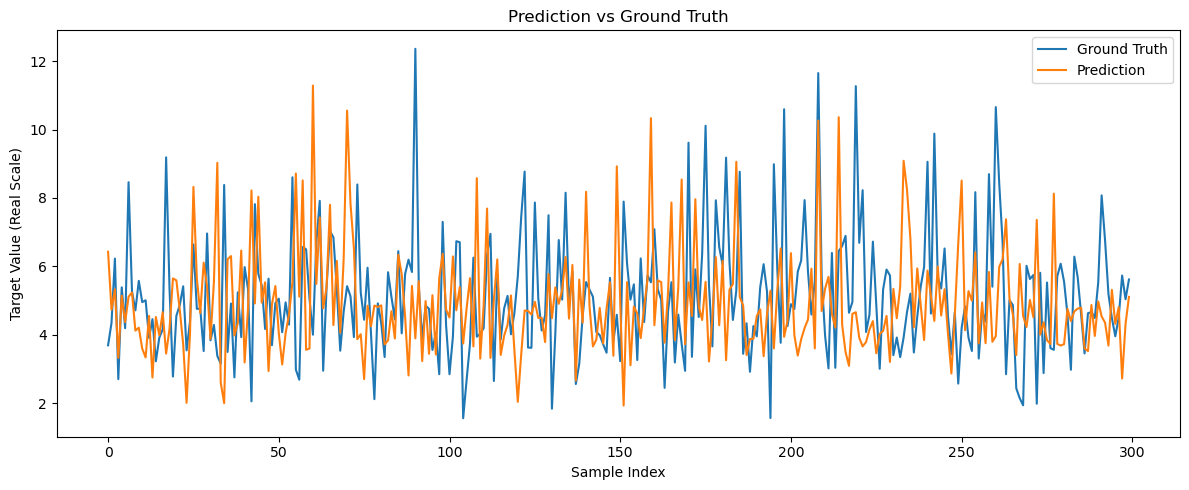

✅ Test R² (normalized): 0.6512


In [8]:
from sklearn.metrics import r2_score
import numpy as np
import torch
import matplotlib.pyplot as plt

# ======================= 0️⃣ numpy → torch =======================

X_test_t = torch.tensor(X_train, dtype=torch.float32)
y_test_t = torch.tensor(y_train, dtype=torch.float32)

@torch.no_grad()
def evaluate_r2_and_plot(model, X_data, y_data, batch_size, y_test_raw, y_mu, y_std):
    model.eval()

    y_true_list = []
    y_pred_list = []

    num_samples = X_data.shape[0]

    for start in range(0, num_samples, batch_size):
        Xb = X_data[start:start + batch_size].to(device)
        yb = y_data[start:start + batch_size].to(device)

        y_hat = model(Xb)

        y_true_list.append(yb.view(-1).cpu().numpy())
        y_pred_list.append(y_hat.view(-1).cpu().numpy())

    # ===== 拼接 =====
    y_true_norm = np.concatenate(y_true_list)
    y_pred_norm = np.concatenate(y_pred_list)

    # ===== R2 (normalized space) =====
    r2 = r2_score(y_true_norm, y_pred_norm)

    # ===== 反归一化预测 =====
    y_pred_real = y_pred_norm * y_std + y_mu
    y_pred_real = y_pred_real.flatten()

    # ===== 真实值直接用 raw =====
    y_true_real = y_test_raw.reshape(-1)

    # ===== 画图 =====
    plt.figure(figsize=(12, 5))

    plt.plot(y_true_real[:300], label="Ground Truth")
    plt.plot(y_pred_real[:300], label="Prediction")

    plt.legend()
    plt.xlabel("Sample Index")
    plt.ylabel("Target Value (Real Scale)")
    plt.title("Prediction vs Ground Truth")

    plt.tight_layout()
    plt.show()

    return r2, y_true_real, y_pred_real

r2, y_true_real, y_pred_real = evaluate_r2_and_plot(
    model,
    X_test_t,
    y_test_t,
    batch_size,
    y_test_raw,
    y_mu,
    y_std
)

print(f"✅ Test R² (normalized): {r2:.4f}")

